# day-29-serving-and-cost — worked solutions & answer key

Solutions to the exercises in [`../lesson.ipynb`](../lesson.ipynb), plus the self-check answer key. **Try each exercise yourself first** — the value is in the attempt, not the answer.

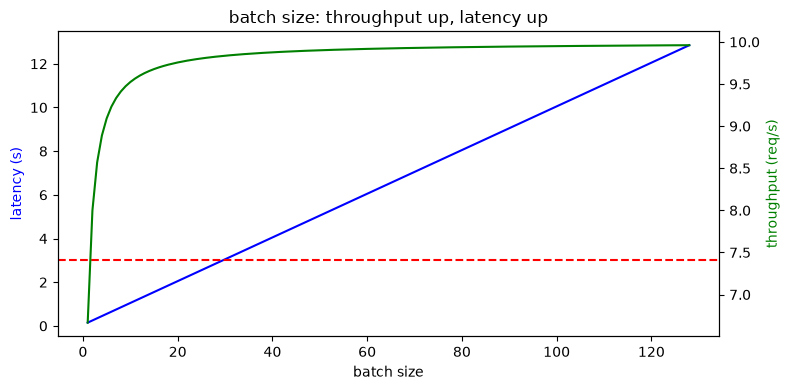

S1: largest batch under 3s SLA = 29, throughput there ~9.8 req/s


In [8]:
# ---- Solution 1 ----
bs = np.arange(1, 129)
lat = np.array([request_latency(2000, 300, b)[0] for b in bs])
thr = bs / lat
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(bs, lat, "b-", label="latency"); ax1.axhline(3.0, ls="--", color="r")
ax1.set_xlabel("batch size"); ax1.set_ylabel("latency (s)", color="b")
ax2 = ax1.twinx(); ax2.plot(bs, thr, "g-"); ax2.set_ylabel("throughput (req/s)", color="g")
plt.title("batch size: throughput up, latency up"); plt.tight_layout(); plt.show()
ok = bs[lat <= 3.0]
print(f"S1: largest batch under 3s SLA = {ok.max()}, throughput there ~{ok.max()/lat[ok.max()-1]:.1f} req/s")

In [9]:
# ---- Solution 2 ----
for ctx in [2_000, 8_000, 32_000, 128_000]:
    m = max_concurrent_requests(ctx)
    gpus_for_200 = math.ceil(200 / m) if m else 999
    print(f"ctx {ctx:>7}: {m:>4} concurrent / GPU   -> {gpus_for_200} GPUs for 200 sessions")
print("S2: long context is a memory problem, not a compute one -- 128k sessions need many GPUs")
print("    just to hold the KV cache. This is why long-context requests are priced higher.")

ctx    2000:  228 concurrent / GPU   -> 1 GPUs for 200 sessions
ctx    8000:   57 concurrent / GPU   -> 4 GPUs for 200 sessions
ctx   32000:   14 concurrent / GPU   -> 15 GPUs for 200 sessions
ctx  128000:    3 concurrent / GPU   -> 67 GPUs for 200 sessions
S2: long context is a memory problem, not a compute one -- 128k sessions need many GPUs
    just to hold the KV cache. This is why long-context requests are priced higher.


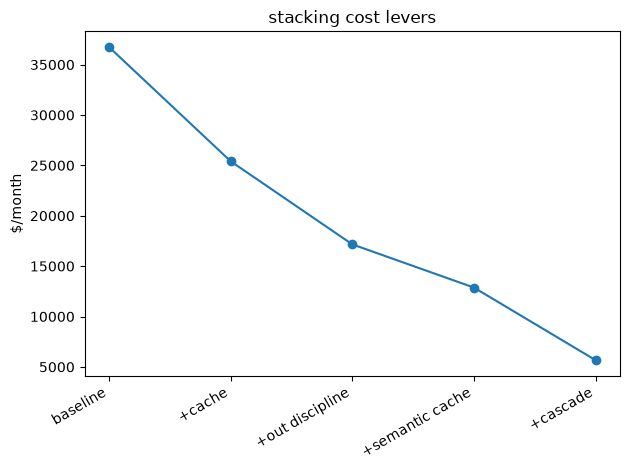

  baseline           $36,750
  +cache             $25,410
  +out discipline    $17,160
  +semantic cache    $12,870
  +cascade           $5,663


In [10]:
# ---- Solution 4 ----
c = base_cost; steps = ["baseline"]; costs = [c]
c = monthly_cost(BASE["calls_per_month"], BASE["in_tok"]*(0.3+0.7*0.1), BASE["out_tok"], BASE["pin"], BASE["pout"]); steps.append("+cache"); costs.append(c)
c = monthly_cost(BASE["calls_per_month"], BASE["in_tok"]*(0.3+0.7*0.1), 140, BASE["pin"], BASE["pout"]); steps.append("+out discipline"); costs.append(c)
c = c * 0.75; steps.append("+semantic cache"); costs.append(c)
c = 0.3*c + 0.7*c/5; steps.append("+cascade"); costs.append(c)
plt.plot(range(len(costs)), costs, "o-"); plt.xticks(range(len(costs)), steps, rotation=30, ha="right")
plt.ylabel("$/month"); plt.title("stacking cost levers"); plt.tight_layout(); plt.show()
for s, x in zip(steps, costs): print(f"  {s:18s} ${x:,.0f}")

### Solutions 3, 5, 6 (sketch)

**S3:** fix `c=8`, sweep `RPS` from `0.5*8/SERVICE_S` to `0.95*8/SERVICE_S`. `p95_latency`
rises gently to ~80% util then hockey-sticks; by 90% it's 2–3× the SLA. Operate at ≤ 75%.

**S5:** `selfhost_cost += 400_000/12` (flat monthly). The break-even token volume roughly
doubles-to-triples — self-hosting needs to save > $33k/month *before* it's worth the team, so
you need to be spending well into six figures on the API first.

**S6:** stale-hit fraction ≈ `min(1, T_days / D_days) * (fraction of cached entries older than
D)`. For data changing every `D=7` days and a target < 1% stale hits, keep TTL `T ≲ 0.07·7 ≈
0.5 days` — or bust the cache on writes to the underlying data (event-driven invalidation
beats TTL guessing).

### Answer key
1. Prefill (parallel, compute-bound, ∝ input tokens) and decode (one token at a time,
   memory-bandwidth-bound, ∝ output tokens). Decode dominates wall-clock.
2. Decode throughput is a fixed pool shared across the batch, so N requests decoding together
   each get ~1/N of the token/s rate.
3. KV-cache memory: each token in context needs K/V vectors in every layer, and
   `(GPU mem − weights) / (context_tokens × kv_bytes_per_token)` caps concurrency regardless
   of compute.
4. Static batching runs a whole batch until the longest request finishes, wasting slots on
   short requests; continuous batching adds/removes requests from the running batch every
   step, recovering 2–4× real throughput.
5. The queue-wait term scales as `1/(cμ − λ)` and blows up as utilisation → 1; the last ~20%
   of nominal capacity is where the latency tail (and your SLA) breaks.
6. Prompt caching → input hygiene → output discipline → semantic cache → model right-sizing/
   cascade → batch → lower effort → (self-host) quantization/spot/continuous batching. The
   first three (caching, hygiene, output discipline) are free; model/effort cuts trade quality
   and must be measured against the eval.
7. At sustained very-high token volume *and* when you can absorb the all-in cost — an
   ML-serving team, load-testing, autoscaling, model updates, security — or when a hard
   data-residency requirement or a heavily-used fine-tune forces it. The raw-token break-even
   is far below the all-in break-even.